# Learning of Joint Probability Distributions

This tutorial introduces the basics of learning joint probability distributions
with `jpt.trees.JPT`.
A JPT is trained on tabular data and learns a compact tree-structured
representation of the joint distribution $P(\mathcal{X})$ over all variables
in the dataset.

We use the [Iris dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-plants-dataset)
throughout this tutorial as a small, well-understood example with both numeric
and symbolic variables.

## Preparing the Data

JPTs consume plain `pandas.DataFrame` objects.
We load the Iris dataset and add the class label as a string column so that
``pyjpt`` can recognise it as a symbolic variable.

In [1]:
import sklearn.datasets
import pandas as pd

dataset = sklearn.datasets.load_iris()
df = pd.DataFrame(columns=dataset.feature_names, data=dataset.data)

target = dataset.target.astype(object)
for idx, name in enumerate(dataset.target_names):
    target[target == idx] = name

df['plant'] = target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),plant
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Inferring Variables from a DataFrame

`jpt.variables.infer_from_dataframe`
inspects the column types of a DataFrame and automatically creates the
appropriate variable type for each column:

| Column dtype | Variable type |
|---|---|
| `float` / `int` (numeric) | `NumericVariable` |
| `object` / `category` (strings) | `SymbolicVariable` |
| `int` (integer domain) | `IntegerVariable` |

Variables can also be defined manually; see
[tutorial_variables](tutorial_variables.ipynb) for details.

In [2]:
from jpt.variables import infer_from_dataframe

variables = infer_from_dataframe(df)

for v in variables:
    print(v, type(v).__name__)

sepal length (cm)[SEPAL LENGTH (CM)_TYPE_N] NumericVariable
sepal width (cm)[SEPAL WIDTH (CM)_TYPE_N] NumericVariable
petal length (cm)[PETAL LENGTH (CM)_TYPE_N] NumericVariable
petal width (cm)[PETAL WIDTH (CM)_TYPE_N] NumericVariable
plant[PLANT_TYPE_S] SymbolicVariable


## Creating and Fitting a JPT

A `jpt.trees.JPT` is created by
passing the variable list to the constructor, and then trained by calling
`fit` with the DataFrame.

The most important stopping criterion is `min_samples_leaf`, which sets the
minimum number of training samples required in each leaf.  Larger values
produce smaller, less overfit trees; smaller values allow finer partitions at
the cost of higher variance.  Fractional values between 0 and 1 are
interpreted as a fraction of the training set size.

In [3]:
from jpt.trees import JPT

model = JPT(variables, min_samples_leaf=0.1)
model.fit(df)
model

<JPT #innernodes = 6, #leaves = 7 (13 total)>

The printed tree shows the decision nodes and leaves that make up the
partition.  Each leaf stores an independent factorised distribution over all
variables.

The number of parameters (i.e. the total size of all leaf distributions) can
be queried directly:

In [4]:
print('Number of leaves:', len(model.leaves))
print('Number of parameters:', model.number_of_parameters())

Number of leaves: 7
Number of parameters: 206


## Effect of Hyperparameters

Three hyperparameters control the tree structure:

| Parameter | Effect |
|---|---|
| `min_samples_leaf` | Minimum samples per leaf (absolute or fraction) |
| `max_depth` | Maximum tree depth |
| `min_impurity_improvement` | Minimum impurity gain required to accept a split |

The plot below shows how `min_samples_leaf` trades off model complexity
(number of parameters) against data fit (log-likelihood on the training set).

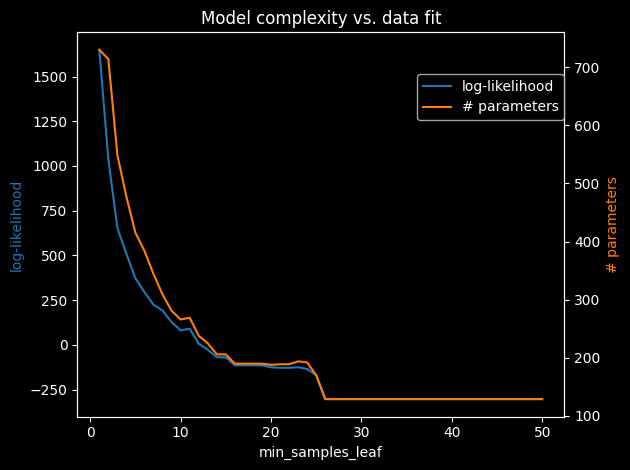

In [5]:
import numpy as np
import matplotlib.pyplot as plt

min_samples_values = range(1, 51)
log_likelihoods = []
n_params = []

for msl in min_samples_values:
    m = JPT(variables, min_samples_leaf=msl)
    m.fit(df)
    ll = np.sum(np.log(m.likelihood(df)))
    log_likelihoods.append(ll)
    n_params.append(m.number_of_parameters())

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(min_samples_values, log_likelihoods, color='tab:blue', label='log-likelihood')
ax2.plot(min_samples_values, n_params, color='tab:orange', label='# parameters')
ax1.set_xlabel('min_samples_leaf')
ax1.set_ylabel('log-likelihood', color='tab:blue')
ax2.set_ylabel('# parameters', color='tab:orange')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))
plt.title('Model complexity vs. data fit')
plt.tight_layout()
plt.show()

As expected, fewer samples per leaf means more leaves and more parameters,
which increases the log-likelihood on the training data.  In practice a value
of 1–10 % of the dataset size is a good starting point.

`min_impurity_improvement` enforces a minimum information-gain threshold
before accepting a split and is a complementary regularisation knob:

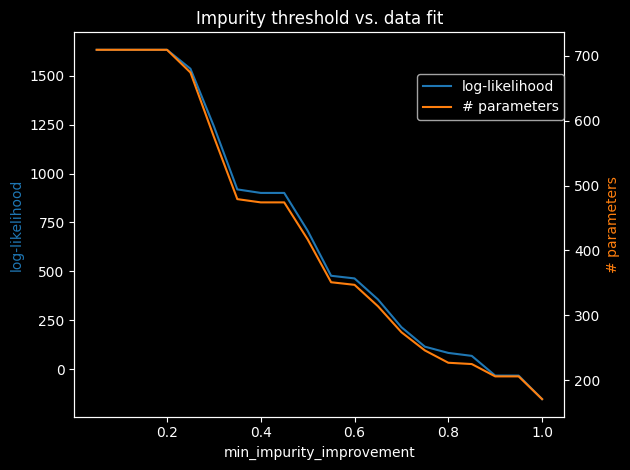

In [6]:
thresholds = [i * 0.05 for i in range(1, 21)]
log_likelihoods_ii = []
n_params_ii = []

for thresh in thresholds:
    m = JPT(variables, min_impurity_improvement=thresh)
    m.fit(df)
    ll = np.sum(np.log(m.likelihood(df)))
    log_likelihoods_ii.append(ll)
    n_params_ii.append(m.number_of_parameters())

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(thresholds, log_likelihoods_ii, color='tab:blue', label='log-likelihood')
ax2.plot(thresholds, n_params_ii, color='tab:orange', label='# parameters')
ax1.set_xlabel('min_impurity_improvement')
ax1.set_ylabel('log-likelihood', color='tab:blue')
ax2.set_ylabel('# parameters', color='tab:orange')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))
plt.title('Impurity threshold vs. data fit')
plt.tight_layout()
plt.show()

## Generative vs. Discriminative Learning

By default a JPT learns the **full joint distribution** $P(\mathcal{X})$ over
all variables (*generative* mode).  This is useful when any variable may play
the role of a query or evidence variable at inference time.

When the task is specifically to predict a set of **target variables** $Y$
from feature variables $X = \mathcal{X} \setminus Y$, *discriminative* mode
optimises the tree splits with respect to $Y$ only.  This concentrates the
model's representational capacity on predicting $Y$ and typically yields
better conditional predictions at the cost of a less accurate model of $X$.

Discriminative mode is activated by passing a `targets` list to the
constructor:

In [7]:
# Discriminative JPT: splits optimised for predicting 'plant'
varnames = {v.name: v for v in variables}

disc_model = JPT(
    variables,
    targets=[varnames['plant']],
    min_samples_leaf=0.1
)
disc_model.fit(df)
disc_model

<JPT #innernodes = 6, #leaves = 7 (13 total)>

## Saving and Loading a Model

A trained model can be persisted to disk and reloaded later without
re-running the training.

In [8]:
import tempfile, os

# Save
tmp = tempfile.mktemp(suffix='.json')
model.save(tmp)
print('Saved to', tmp)

# Load
loaded_model = JPT.load(tmp)
print('Loaded:', loaded_model)

os.remove(tmp)

Saved to /tmp/tmp0he4m98k.json
Loaded: JPT#innernodes = 6, #leaves = 7 (13 total)


The loaded model is identical to the original and can be used for inference
without any further setup.  See
[tutorial_reasoning](tutorial_reasoning.ipynb) for how to query a trained
model.